# Data Inspection - Sentinel-2 Brownfield Detection Stoke-on-Trent
This notebook investigates the structure, dimensions and pixel statistics of the Sentinel-2 L2A image captured on 25-05-2026 over Stoke-on-Trent.

## Objectives
- Confirm image dimensions and pixel count.
- Check pixel value ranges per band.
- Visually inspect the true colour image.
- Identify any data quality issues.

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

## File Structure Investigation
Confirming the location and names of the band of files we will be working with.

In [2]:
PROJECT_ROOT = Path(__file__).parent.parent if '__file__' in dir() else Path(os.getcwd()).parent
safe_path = str(PROJECT_ROOT / "raw_data" / "S2C_MSIL2A_20260525T110621_N0512_R137_T30UWD_20260525T144513.SAFE" / "S2C_MSIL2A_20260525T110621_N0512_R137_T30UWD_20260525T144513.SAFE")
print(safe_path)

C:\Users\lward\workspace\sentinel2-brownfield-stoke\raw_data\S2C_MSIL2A_20260525T110621_N0512_R137_T30UWD_20260525T144513.SAFE\S2C_MSIL2A_20260525T110621_N0512_R137_T30UWD_20260525T144513.SAFE


**Note:** After extraction with 7-Zip the SAFE folder was nested inside itself. 
The correct data path requires navigating into the inner SAFE folder.

In [3]:
contents = os.listdir(safe_path)
print(f"Number of items: {len(contents)}")
for item in contents:
    print(item)

Number of items: 8
DATASTRIP
GRANULE
HTML
INSPIRE.xml
manifest.safe
MTD_MSIL2A.xml
rep_info
S2C_MSIL2A_20260525T110621_N0512_R137_T30UWD_20260525T144513-ql.jpg


In [4]:
img_data_path = os.path.join(safe_path, "GRANULE")
contents = os.listdir(img_data_path)
for item in contents:
    print(item)

L2A_T30UWD_A008973_20260525T111007


In [5]:
img_data_path = os.path.join(safe_path, "GRANULE", "L2A_T30UWD_A008973_20260525T111007", "IMG_DATA")
contents = os.listdir(img_data_path)
for item in contents:
    print(item)

R10m
R20m
R60m


In [6]:
for resolution in contents:
    res_path = os.path.join(img_data_path, resolution)
    files = os.listdir(res_path)
    print(f"\n{resolution}:")
    for f in files:
        print(f"  {f}")


R10m:
  T30UWD_20260525T110621_AOT_10m.jp2
  T30UWD_20260525T110621_B02_10m.jp2
  T30UWD_20260525T110621_B03_10m.jp2
  T30UWD_20260525T110621_B04_10m.jp2
  T30UWD_20260525T110621_B08_10m.jp2
  T30UWD_20260525T110621_TCI_10m.jp2
  T30UWD_20260525T110621_WVP_10m.jp2

R20m:
  T30UWD_20260525T110621_AOT_20m.jp2
  T30UWD_20260525T110621_B01_20m.jp2
  T30UWD_20260525T110621_B02_20m.jp2
  T30UWD_20260525T110621_B03_20m.jp2
  T30UWD_20260525T110621_B04_20m.jp2
  T30UWD_20260525T110621_B05_20m.jp2
  T30UWD_20260525T110621_B06_20m.jp2
  T30UWD_20260525T110621_B07_20m.jp2
  T30UWD_20260525T110621_B11_20m.jp2
  T30UWD_20260525T110621_B12_20m.jp2
  T30UWD_20260525T110621_B8A_20m.jp2
  T30UWD_20260525T110621_SCL_20m.jp2
  T30UWD_20260525T110621_TCI_20m.jp2
  T30UWD_20260525T110621_WVP_20m.jp2

R60m:
  T30UWD_20260525T110621_AOT_60m.jp2
  T30UWD_20260525T110621_B01_60m.jp2
  T30UWD_20260525T110621_B02_60m.jp2
  T30UWD_20260525T110621_B03_60m.jp2
  T30UWD_20260525T110621_B04_60m.jp2
  T30UWD_20260525

## Finding: File Structure Confirmed
All expected band files are present across R10m, R20m and R60m folders.
B09 only available at 60m resolution.
B10 not present in this product.

## 2. Image Dimensions and Pixel Statistics
Checking dimensions and pixel value ranges for all JP2 files in R10m, R20m and R60m.

### 2a. R10m File Statistics
Checking dimensions and pixel value ranges for all JP2 files in R10m.

In [7]:
r10m_path = os.path.join(img_data_path, "R10m")

for filename in os.listdir(r10m_path):
    if filename.endswith(".jp2"):
        filepath = os.path.join(r10m_path, filename)
        with rasterio.open(filepath) as src:
            data = src.read(1)
            print(f"File: {filename}")
            print(f"  Shape: {data.shape}")
            print(f"Width: {src.width} pixels")
            print(f"Height: {src.height} pixels")
            print(f"Number of bands: {src.count}")
            print(f"Coordinate system: {src.crs}")
            print(f"Data type: {src.dtypes[0]}")
            print(f"Min value: {data.min()}")
            print(f"Max value: {data.max()}")
            print(f"Mean value: {data.mean():.2f}")
            print()

File: T30UWD_20260525T110621_AOT_10m.jp2
  Shape: (10980, 10980)
Width: 10980 pixels
Height: 10980 pixels
Number of bands: 1
Coordinate system: EPSG:32630
Data type: uint16
Min value: 0
Max value: 180
Mean value: 107.69

File: T30UWD_20260525T110621_B02_10m.jp2
  Shape: (10980, 10980)
Width: 10980 pixels
Height: 10980 pixels
Number of bands: 1
Coordinate system: EPSG:32630
Data type: uint16
Min value: 0
Max value: 20277
Mean value: 1035.37

File: T30UWD_20260525T110621_B03_10m.jp2
  Shape: (10980, 10980)
Width: 10980 pixels
Height: 10980 pixels
Number of bands: 1
Coordinate system: EPSG:32630
Data type: uint16
Min value: 0
Max value: 19154
Mean value: 1256.27

File: T30UWD_20260525T110621_B04_10m.jp2
  Shape: (10980, 10980)
Width: 10980 pixels
Height: 10980 pixels
Number of bands: 1
Coordinate system: EPSG:32630
Data type: uint16
Min value: 0
Max value: 18217
Mean value: 1132.97

File: T30UWD_20260525T110621_B08_10m.jp2
  Shape: (10980, 10980)
Width: 10980 pixels
Height: 10980 pixels
N

**Finding — R10m Band Statistics:**
- All bands: 10,980 x 10,980 pixels, EPSG:32630, consistent across all files
- Spectral bands (B02, B03, B04, B08) are uint16 with values ranging 0 to ~20,000
- B08 NIR has significantly higher mean (3,489) than visible bands (~1,000-1,250) — 
  indicates strong vegetation reflectance across the tile
- TCI is different — uint8 (0-255), 3 bands — pre-made RGB composite, not raw reflectance
- AOT and WVP operate on a different scale — atmospheric products, not surface reflectance
- All bands have min value 0 — nodata pixels present outside tile boundary
- Normalisation must account for actual observed range, not theoretical uint16 maximum

### 2b. R20m File Statistics
Checking dimensions and pixel value ranges for all JP2 files in R20m.

In [8]:
r20m_path = os.path.join(img_data_path, "R20m")

for filename in os.listdir(r20m_path):
    if filename.endswith(".jp2"):
        filepath = os.path.join(r20m_path, filename)
        with rasterio.open(filepath) as src:
            data = src.read(1)
            print(f"File: {filename}")
            print(f"  Shape: {data.shape}")
            print(f"Width: {src.width} pixels")
            print(f"Height: {src.height} pixels")
            print(f"Number of bands: {src.count}")
            print(f"Coordinate system: {src.crs}")
            print(f"Data type: {src.dtypes[0]}")
            print(f"Min value: {data.min()}")
            print(f"Max value: {data.max()}")
            print(f"Mean value: {data.mean():.2f}")
            print()

File: T30UWD_20260525T110621_AOT_20m.jp2
  Shape: (5490, 5490)
Width: 5490 pixels
Height: 5490 pixels
Number of bands: 1
Coordinate system: EPSG:32630
Data type: uint16
Min value: 0
Max value: 180
Mean value: 107.69

File: T30UWD_20260525T110621_B01_20m.jp2
  Shape: (5490, 5490)
Width: 5490 pixels
Height: 5490 pixels
Number of bands: 1
Coordinate system: EPSG:32630
Data type: uint16
Min value: 0
Max value: 14616
Mean value: 1000.16

File: T30UWD_20260525T110621_B02_20m.jp2
  Shape: (5490, 5490)
Width: 5490 pixels
Height: 5490 pixels
Number of bands: 1
Coordinate system: EPSG:32630
Data type: uint16
Min value: 0
Max value: 20222
Mean value: 1034.77

File: T30UWD_20260525T110621_B03_20m.jp2
  Shape: (5490, 5490)
Width: 5490 pixels
Height: 5490 pixels
Number of bands: 1
Coordinate system: EPSG:32630
Data type: uint16
Min value: 0
Max value: 18829
Mean value: 1255.57

File: T30UWD_20260525T110621_B04_20m.jp2
  Shape: (5490, 5490)
Width: 5490 pixels
Height: 5490 pixels
Number of bands: 1
Co

**Finding — R20m Band Statistics:**
- All bands: 5490 x 5490 pixels, EPSG:32630, consistent across all files
- Spectral bands (B01, B02, B03, B04, B05, B06, B07, B8A, B11, B12) are uint16 with values ranging 0 to ~20,000
- B8A has significantly higher mean (3,579) than visible bands (~1,000-1,250) — 
  indicates strong vegetation reflectance across the tile
- TCI is different — uint8 (0-255), 3 bands — pre-made RGB composite, not raw reflectance
- AOT and WVP operate on a different scale — atmospheric products, not surface reflectance
- SCL max value is 11. It is the scene classification map with land cover class ranging from 0-11
- All bands have min value 0 — nodata pixels present outside tile boundary
- Normalisation must account for actual observed range, not theoretical uint16 maximum

### 2c. R60m File Statistics
Checking dimensions and pixel value ranges for all JP2 files in R60m.

In [9]:
r60m_path = os.path.join(img_data_path, "R60m")

for filename in os.listdir(r60m_path):
    if filename.endswith(".jp2"):
        filepath = os.path.join(r60m_path, filename)
        with rasterio.open(filepath) as src:
            data = src.read(1)
            print(f"File: {filename}")
            print(f"  Shape: {data.shape}")
            print(f"Width: {src.width} pixels")
            print(f"Height: {src.height} pixels")
            print(f"Number of bands: {src.count}")
            print(f"Coordinate system: {src.crs}")
            print(f"Data type: {src.dtypes[0]}")
            print(f"Min value: {data.min()}")
            print(f"Max value: {data.max()}")
            print(f"Mean value: {data.mean():.2f}")
            print()

File: T30UWD_20260525T110621_AOT_60m.jp2
  Shape: (1830, 1830)
Width: 1830 pixels
Height: 1830 pixels
Number of bands: 1
Coordinate system: EPSG:32630
Data type: uint16
Min value: 0
Max value: 180
Mean value: 107.69

File: T30UWD_20260525T110621_B01_60m.jp2
  Shape: (1830, 1830)
Width: 1830 pixels
Height: 1830 pixels
Number of bands: 1
Coordinate system: EPSG:32630
Data type: uint16
Min value: 0
Max value: 12106
Mean value: 1000.16

File: T30UWD_20260525T110621_B02_60m.jp2
  Shape: (1830, 1830)
Width: 1830 pixels
Height: 1830 pixels
Number of bands: 1
Coordinate system: EPSG:32630
Data type: uint16
Min value: 0
Max value: 9332
Mean value: 1034.77

File: T30UWD_20260525T110621_B03_60m.jp2
  Shape: (1830, 1830)
Width: 1830 pixels
Height: 1830 pixels
Number of bands: 1
Coordinate system: EPSG:32630
Data type: uint16
Min value: 0
Max value: 9342
Mean value: 1255.57

File: T30UWD_20260525T110621_B04_60m.jp2
  Shape: (1830, 1830)
Width: 1830 pixels
Height: 1830 pixels
Number of bands: 1
Coor

**Finding — R60m Band Statistics:**
- All bands: 1830 x 1830 pixels, EPSG:32630, consistent across all files
- Spectral bands (B01, B02, B03, B04, B05, B06, B07, B8A, B09, B11, B12) are uint16 with values ranging 0 to ~9332
  lower than R10m (~20,000) because pixel values 
  are averaged over a larger area at lower resolution, smoothing out extreme values
- B09 is only present for R60.
- TCI is different — uint8 (0-255), 3 bands — pre-made RGB composite, not raw reflectance
- AOT and WVP operate on a different scale — atmospheric products, not surface reflectance
- SCL max value is 11. It is the scene classification map with land cover class ranging from 0-11
- All bands have min value 0 — nodata pixels present outside tile boundary
- Normalisation must account for actual observed range, not theoretical uint16 maximum

## 3. Visual Inspection
Displaying the TCI true colour image to visually identify land cover types 
including brownfield land, vegetation, urban fabric and water.

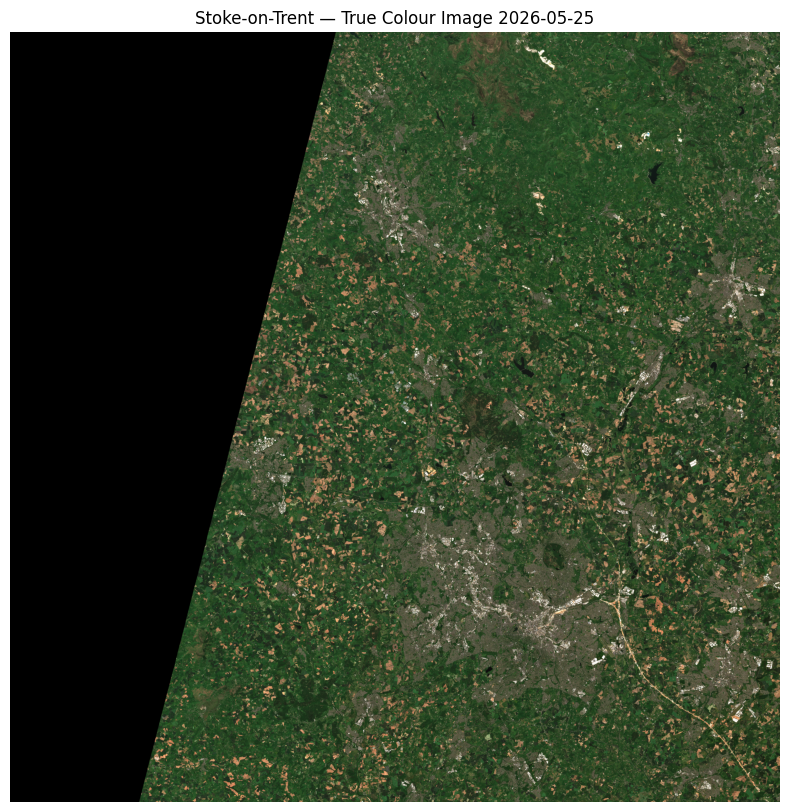

In [10]:
TCI_10m_path = os.path.join(img_data_path, "R10m", "T30UWD_20260525T110621_TCI_10m.jp2")

with rasterio.open(TCI_10m_path) as src:
    tci = src.read([1, 2, 3])
    tci = tci.transpose(1, 2, 0)
    plt.figure(figsize=(10, 10))
    plt.imshow(tci)
    plt.title("Stoke-on-Trent — True Colour Image 2026-05-25")
    plt.axis("off")
    plt.show()

**Finding — Visual Inspection:**
- Black area on left confirms nodata pixels outside tile boundary
- Urban core of Stoke-on-Trent visible as grey cluster in centre
- Brownfield land visible as distinctive brown/orange patches concentrated around urban core
- Dark green areas are vegetation — fields and woodland
- Water not clearly visible at this resolution in true colour
- Brown/orange spectral signature of brownfield land should be separable by PCA

## 4. Data Quality Check — Scene Classification Map
Examining the SCL band to assess cloud cover, shadow and nodata pixels 
over the Stoke-on-Trent AOI.

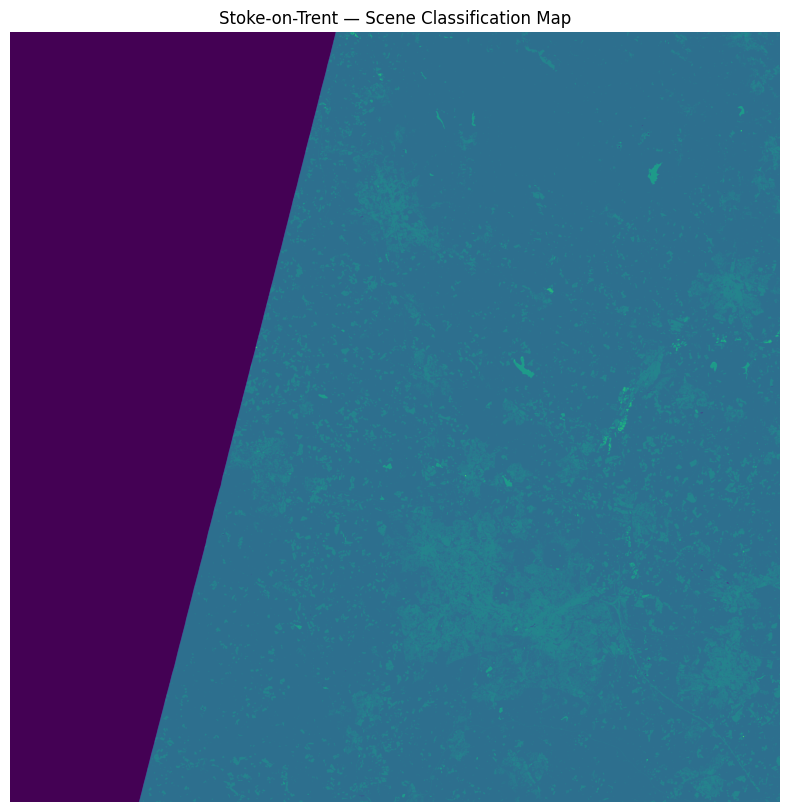

In [11]:
SCL_20m_path = os.path.join(img_data_path, "R20m", "T30UWD_20260525T110621_SCL_20m.jp2")

with rasterio.open(SCL_20m_path) as src:
    scl = src.read(1)
    plt.figure(figsize=(10, 10))
    plt.imshow(scl)
    plt.title("Stoke-on-Trent — Scene Classification Map")
    plt.axis("off")
    plt.show()

In [12]:
unique_values = np.unique(scl)
print("SCL classes present:", unique_values)
for value in unique_values:
    count = np.sum(scl == value)
    percentage = (count / scl.size) * 100
    print(f"Class {value:2d}: {count:8d} pixels ({percentage:.2f}%)")

SCL classes present: [ 0  2  3  4  5  6  7  8  9 10 11]
Class  0:  8916450 pixels (29.58%)
Class  2:     4086 pixels (0.01%)
Class  3:        1 pixels (0.00%)
Class  4: 18329816 pixels (60.82%)
Class  5:  2805178 pixels (9.31%)
Class  6:    50757 pixels (0.17%)
Class  7:    33320 pixels (0.11%)
Class  8:      130 pixels (0.00%)
Class  9:       16 pixels (0.00%)
Class 10:      319 pixels (0.00%)
Class 11:       27 pixels (0.00%)


**Finding — SCL Data Quality Check:**
- Class 0 (No data): 29.58% — tile boundary, expected
- Class 4 (Vegetation): 60.82% — majority of valid pixels, large rural area surrounding Stoke
- Class 5 (Bare soil): 9.31% — over 2.8 million pixels — brownfield signal plus agricultural bare soil
- Class 6 (Water): 0.17% — River Trent and canal network confirmed present
- Cloud classes (8, 9, 10, 11): combined less than 0.01% — image is effectively cloud free
- Image quality is excellent for PCA analysis — minimal cloud contamination

## 5. Key Observations and Design Implications

### Band Selection
Ten bands selected for analysis — B02, B03, B04, B05, B06, B07, B08, B8A, B11, B12.
These cover visible light, vegetation and moisture content which should help distinguish 
brownfield land, green space, built up areas and water.
B01 and B09 excluded as they measure atmospheric conditions rather than the ground surface.

### Resolution
All bands will be processed at 20m resolution. Higher resolution bands will be 
downsampled to match. This keeps processing fast while still providing enough 
detail to identify brownfield sites across the city.

### Nodata Pixels
Approximately 30% of the image falls outside the valid tile boundary. 
These pixels must be removed before analysis to avoid distorting the results.

### Cloud Cover
Cloud contamination is negligible at less than 0.01% of valid pixels. 
The heatwave date produced an excellent quality image.

### Brownfield Signal
Just over 9% of valid pixels are flagged as bare soil — over 2.8 million pixels. 
This confirms a strong brownfield signal is present in the data. 
B11 and B12 are expected to be the strongest indicators for separating 
brownfield land from vegetation due to their sensitivity to soil moisture.